# 02 Exploratory Data Analysis

This notebook explores the cleaned Adult dataset to inform modelling and preprocessing decisions. 

In [2]:
import os
import matplotlib.pyplot as plt
from pathlib import Path

# Project root = parent of the notebooks folder
PROJECT_ROOT = Path.cwd().resolve().parent  # assumes notebook is run from /notebooks

def save_and_show(fig_name: str):
    figures_dir = PROJECT_ROOT / "outputs" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(figures_dir / f"{fig_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Styling: Economist-inspired minimal style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelcolor': '#333333',
    'axes.edgecolor': '#cccccc',
    'grid.color': '#eeeeee',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.figsize': (10, 6)
})
COLORS = ['#475ED1', '#E3120B'] # Neutrals/Economist-like blue/red

df = pd.read_csv('../data/processed/adult_cleaned.csv')
print(f"Dataset reloaded. Shape: {df.shape}")

Dataset reloaded. Shape: (48842, 14)


## Is the target variable balanced enough for simple classification?

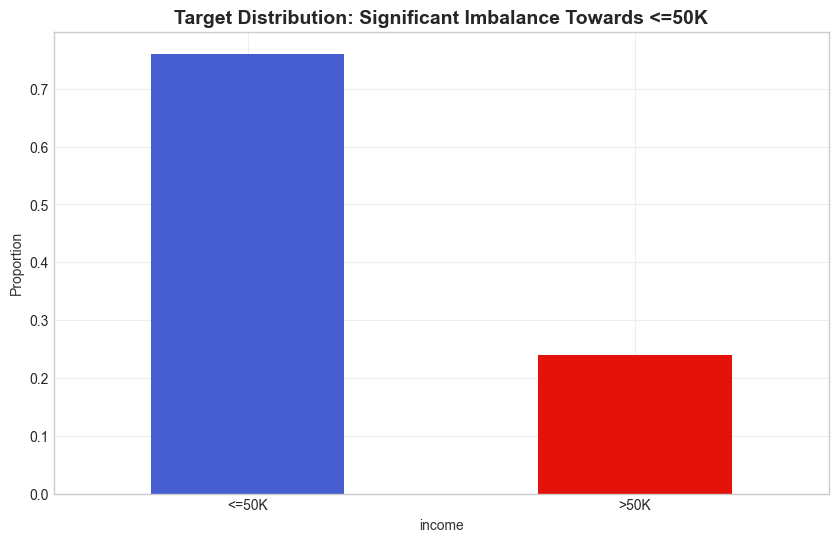

In [4]:
ax = df['income'].value_counts(normalize=True).plot(kind='bar', color=COLORS, rot=0)
ax.set_title("Target Distribution: Significant Imbalance Towards <=50K")
ax.set_ylabel("Proportion")
save_and_show("eda_target_distribution")

### Interpretation
- **Observation**: The dataset exhibits a **76%** to **24%** imbalance.
- **Decision**: Modelling must consider class weights or evaluation metrics beyond simple accuracy (e.g., F1-score or precision-recall AUC).

## How does age relate to the probability of earning over 50K?

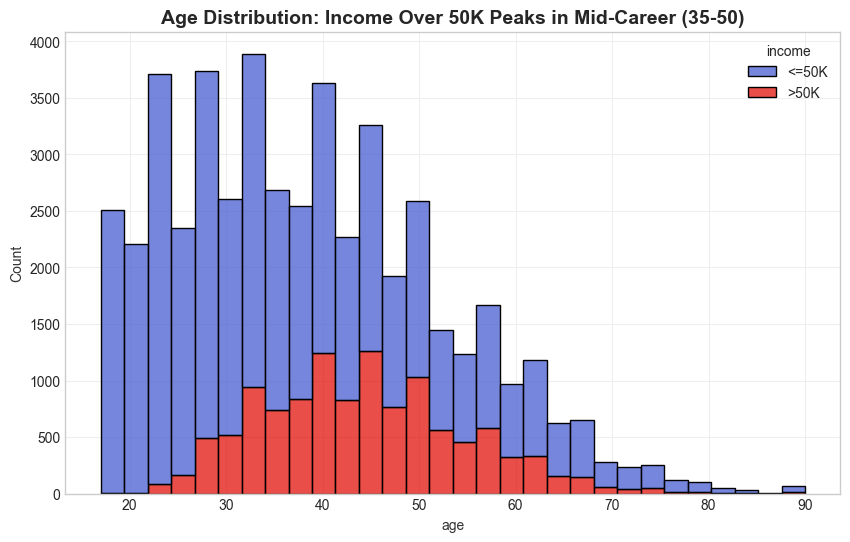

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='income', multiple='stack', palette=COLORS, bins=30)
plt.title("Age Distribution: Income Over 50K Peaks in Mid-Career (35-50)")
save_and_show("eda_age_distribution")

### Interpretation
- **Observation**: Earners over 50K are concentrated in the **35-55** age bracket; low income is dominant among younger workers (**<30**).
- **Decision**: Age is a strong non-linear predictor; consider binning if linear models are used, or keep as-is for tree-based models.

## Do longer work weeks significantly increase higher-income probability?

/var/folders/f9/pszv1q012cl527b9_3j1wjt00000gp/T/ipykernel_3047/3732547068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y='hours-per-week', palette=COLORS)


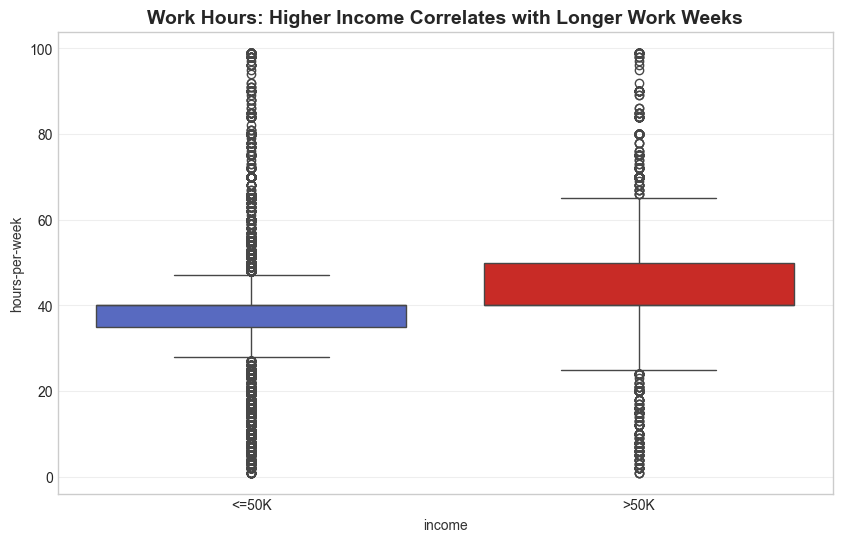

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='income', y='hours-per-week', palette=COLORS)
plt.title("Work Hours: Higher Income Correlates with Longer Work Weeks")
save_and_show("eda_work_hours_worked")

### Interpretation
- **Observation**: The median work week for >50K earners is higher (**40** hours with a larger upper spread) compared to <=50K earners.
- **Decision**: `hours-per-week` contains extreme outliers (up to **99**) which may require robust scaling.

## Which education levels yield the highest proportion of >50K earners?

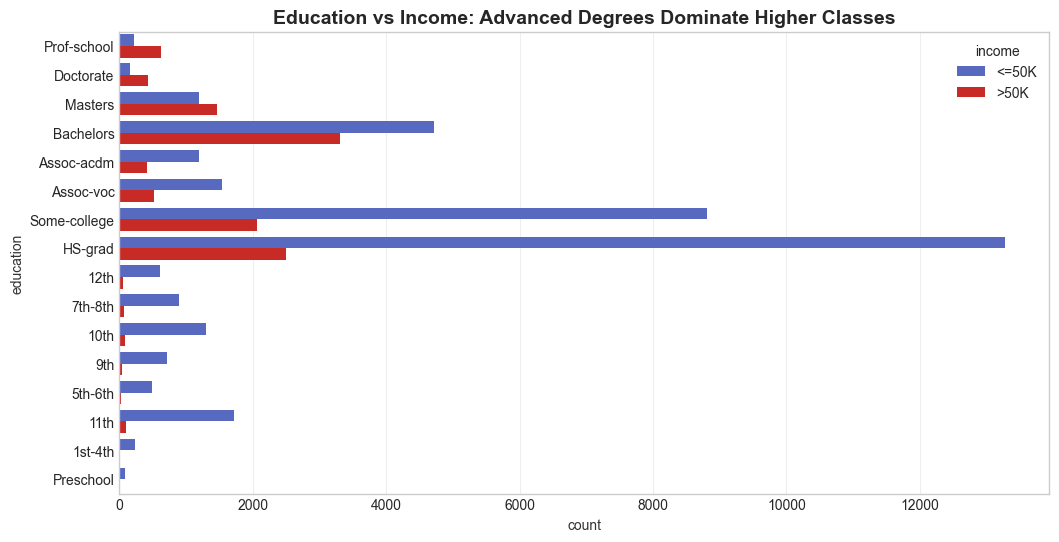

In [7]:
plt.figure(figsize=(12, 6))
education_order = df.groupby('education')['income'].value_counts(normalize=True).unstack()['>50K'].sort_values(ascending=False).index
sns.countplot(data=df, y='education', hue='income', order=education_order, palette=COLORS)
plt.title("Education vs Income: Advanced Degrees Dominate Higher Classes")
save_and_show("eda_education_vs_income")

### Interpretation
- **Observation**: Doctorate, Prof-school, and Masters have the highest **ratio** of high earners, while HS-grad has the highest **volume** of low earners.
- **Decision**: Consolidate low-frequency education categories (e.g., specific grade levels) to reduce dimensionality.

## How sparse is the capital-gain distribution and how should we scale it?

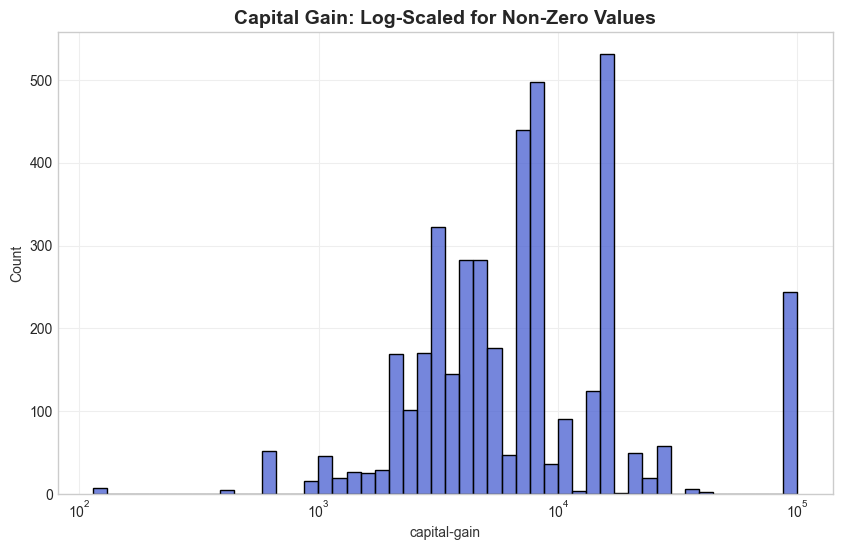

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['capital-gain'][df['capital-gain'] > 0], bins=50, color=COLORS[0], log_scale=True)
plt.title("Capital Gain: Log-Scaled for Non-Zero Values")
save_and_show("eda_capital_gain_distribution")

### Interpretation
- **Observation**: Most values are **0**; non-zero values are heavily skewed with a peak at **99,999**.
- **Decision**: Use a power transformer or log transformation for this feature to mitigate the impact of the heavy right tail.

## Where are the missing values concentrated?

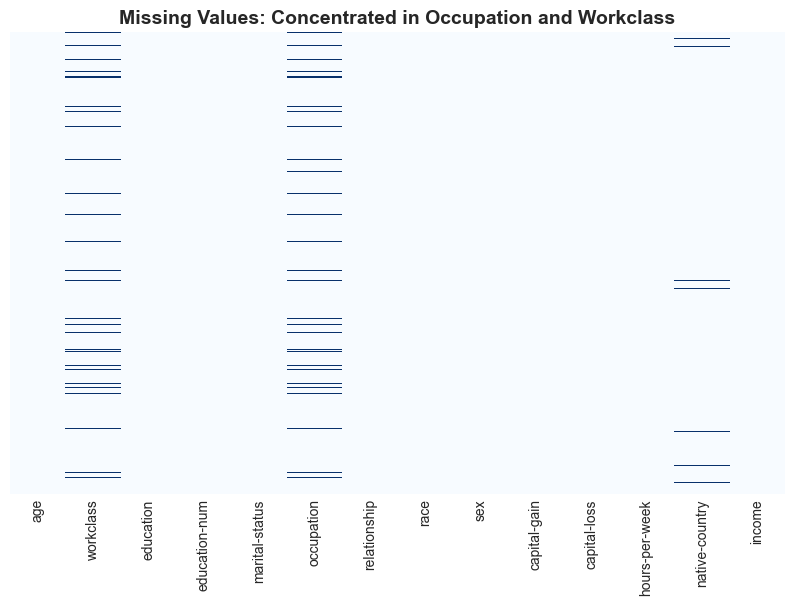

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='Blues')
plt.title("Missing Values: Concentrated in Occupation and Workclass")
save_and_show("eda_missing_values")

### Interpretation
- **Observation**: Missingness is visible as horizontal bands, specifically in `occupation` and `workclass`. Appears structural//patterned, so missing values are not random errors. 
- **Decision**: Impute categorical missing values using a 'Missing' category or the mode, as they appear frequently together.

In [10]:
summary_table = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notnull().sum().values
})

summary_table

,Variable,Data Type,Non-Null Count
age,age,int64,48842
workclass,workclass,str,46043
education,education,str,48842
education-num,education-num,int64,48842
marital-status,marital-status,str,48842
occupation,occupation,str,46033
relationship,relationship,str,48842
race,race,str,48842
sex,sex,str,48842
capital-gain,capital-gain,int64,48842
